# Libraries

In [1]:
import sys
import cv2
import torch
from matplotlib import pyplot as plt
import torch
# from efficientnet_pytorch import EfficientNet
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch import nn, optim
import numpy as np
import os
import argparse
from tqdm import tqdm
from sklearn.model_selection import train_test_split  
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import re

from PIL import Image
from torch.nn import functional as F

import cv2
import torch
import os
from tqdm import tqdm
import ptlflow
from ptlflow.utils import flow_utils
import re
import numpy as np
import concurrent.futures
import timm
import time 
import random
from torch.amp import autocast, GradScaler


d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[!!alt_cuda_corr is not compiled!!]


# Load Frames

In [2]:

frames_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames\\'

frames = os.listdir(frames_dir)
print(f"Total frames: {len(frames)}")


Total frames: 9135


In [3]:

def natural_sort_key(s):
    return int(re.search(r'(\d+)', s).group())

frames = sorted(os.listdir(frames_dir), key=natural_sort_key)

# Check actual frame count
print(f"Total frames: {len(frames)}")
print(f"First frame: {frames[0]}")
print(f"Last frame: {frames[-1]}")
print(f"Expected last frame: frame_{len(frames)-1}.jpg")
print(frames[:20])


Total frames: 9135
First frame: frame_0.png
Last frame: frame_9134.png
Expected last frame: frame_9134.jpg
['frame_0.png', 'frame_1.png', 'frame_2.png', 'frame_3.png', 'frame_4.png', 'frame_5.png', 'frame_6.png', 'frame_7.png', 'frame_8.png', 'frame_9.png', 'frame_10.png', 'frame_11.png', 'frame_12.png', 'frame_13.png', 'frame_14.png', 'frame_15.png', 'frame_16.png', 'frame_17.png', 'frame_18.png', 'frame_19.png']


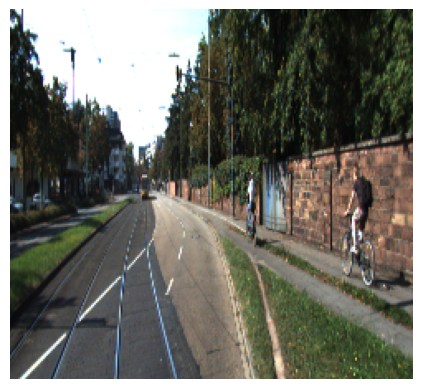

In [4]:
img = cv2.imread(os.path.join(frames_dir, frames[0]))
img = cv2.resize(img, (244, 224))   
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Get Flow

In [5]:

def preprocess_small(img, gamma=1.5, size=(224, 224)):
    img = cv2.convertScaleAbs(img, alpha=1.5, beta=0)
    # img = cv2.resize(img, size)
    return img


In [9]:


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ptlflow.get_model('dpflow', ckpt_path='kitti').to(device)
model.eval()

max_val, min_val = 255.0, 0.0  

frames_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames'
flows_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\flows_process_then_resize'
separate_frames_indices = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\video_separation_indices.txt'
os.makedirs(flows_dir, exist_ok=True)

with open(separate_frames_indices, 'r') as f:
    line_indices = [int(line.strip()) for line in f.readlines()]

frames = sorted(os.listdir(frames_dir), key=natural_sort_key)

def save_flow(flow_rgb, flow_filename):
    flow_rgb = cv2.resize(flow_rgb, (224, 224))
    plt.imsave(flow_filename, flow_rgb)

with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
    for i in tqdm(range(len(frames) - 1), desc="Optical Flow"):
        
        if i+1 in line_indices :
            continue

        img1_path = os.path.join(frames_dir, frames[i])
        img2_path = os.path.join(frames_dir, frames[i+1])
        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)
        if img1 is None or img2 is None:
            print(f"Warning: Could not read {img1_path} or {img2_path}")
            continue

        img1 = preprocess_small(img1)
        img2 = preprocess_small(img2)

        # Convert to tensor and move to device in one step
        imgs = np.stack([img1, img2], axis=0)
        imgs = torch.from_numpy(imgs).permute(0, 3, 1, 2).float().unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model({"images": imgs})
        flow = pred['flows'][0, 0].cpu()

        # * Normalized Flow using Tensor Input
        flow_rgb = flow_utils.flow_to_rgb(flow, background='dark').permute(1, 2, 0).numpy()

        # * Manually Normalized Flow using Numpy Input
        # flow = flow.permute(1, 2, 0).detach().numpy()
        # flow_viz = flow_utils.flow_to_rgb(flow, background='dark')
        # flow_viz = flow_viz.astype(np.float32)
        # flow_rgb = (flow_viz - min_val) / (max_val - min_val)

        flow_filename = os.path.join(flows_dir, f'flow_{i}.png')
        executor.submit(save_flow, flow_rgb, flow_filename)

        # Free up memory
        del imgs, pred, flow, flow_rgb
        torch.cuda.empty_cache()



2026-03-30 09:53:42.872 | INFO     | ptlflow.models.dpflow.dpflow:__init__:158 - DPFlow: --model.pyramid_levels is not set, the number of pyramid levels will be inferred from the input size.
Downloading: "https://github.com/hmorimitsu/ptlflow/releases/download/weights1/dpflow-kitti-4e97eac6.ckpt" to C:\Users\pc\.cache\torch\hub\checkpoints\dpflow-kitti-4e97eac6.ckpt
100%|██████████| 38.4M/38.4M [00:22<00:00, 1.78MB/s]
2026-03-30 09:54:06.254 | INFO     | ptlflow:restore_model:283 - Restored model state from checkpoint: kitti


In [9]:


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ptlflow.get_model('dpflow', ckpt_path='kitti').to(device)
model.eval()

max_val, min_val = 255.0, 0.0  

frames_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frames'
flows_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\flows_process_then_resize'
separate_frames_indices = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\video_separation_indices.txt'
os.makedirs(flows_dir, exist_ok=True)

with open(separate_frames_indices, 'r') as f:
    line_indices = [int(line.strip()) for line in f.readlines()]

frames = sorted(os.listdir(frames_dir), key=natural_sort_key)

def save_flow(flow_rgb, flow_filename):
    flow_rgb = cv2.resize(flow_rgb, (224, 224))
    plt.imsave(flow_filename, flow_rgb)

with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
    for i in tqdm(range(len(frames) - 1), desc="Optical Flow"):
        
        if i+1 in line_indices :
            continue

        img1_path = os.path.join(frames_dir, frames[i])
        img2_path = os.path.join(frames_dir, frames[i+1])
        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)
        if img1 is None or img2 is None:
            print(f"Warning: Could not read {img1_path} or {img2_path}")
            continue

        img1 = preprocess_small(img1)
        img2 = preprocess_small(img2)

        # Convert to tensor and move to device in one step
        imgs = np.stack([img1, img2], axis=0)
        imgs = torch.from_numpy(imgs).permute(0, 3, 1, 2).float().unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model({"images": imgs})
        flow = pred['flows'][0, 0].cpu()

        # * Normalized Flow using Tensor Input
        flow_rgb = flow_utils.flow_to_rgb(flow, background='dark').permute(1, 2, 0).numpy()

        # * Manually Normalized Flow using Numpy Input
        # flow = flow.permute(1, 2, 0).detach().numpy()
        # flow_viz = flow_utils.flow_to_rgb(flow, background='dark')
        # flow_viz = flow_viz.astype(np.float32)
        # flow_rgb = (flow_viz - min_val) / (max_val - min_val)

        flow_filename = os.path.join(flows_dir, f'flow_{i}.png')
        executor.submit(save_flow, flow_rgb, flow_filename)

        # Free up memory
        del imgs, pred, flow, flow_rgb
        torch.cuda.empty_cache()



2025-09-10 15:53:52.828 | INFO     | ptlflow.models.dpflow.dpflow:__init__:158 - DPFlow: --model.pyramid_levels is not set, the number of pyramid levels will be inferred from the input size.
2025-09-10 15:53:52.961 | INFO     | ptlflow:restore_model:283 - Restored model state from checkpoint: kitti
Optical Flow: 100%|██████████| 2123/2123 [05:48<00:00,  6.09it/s]


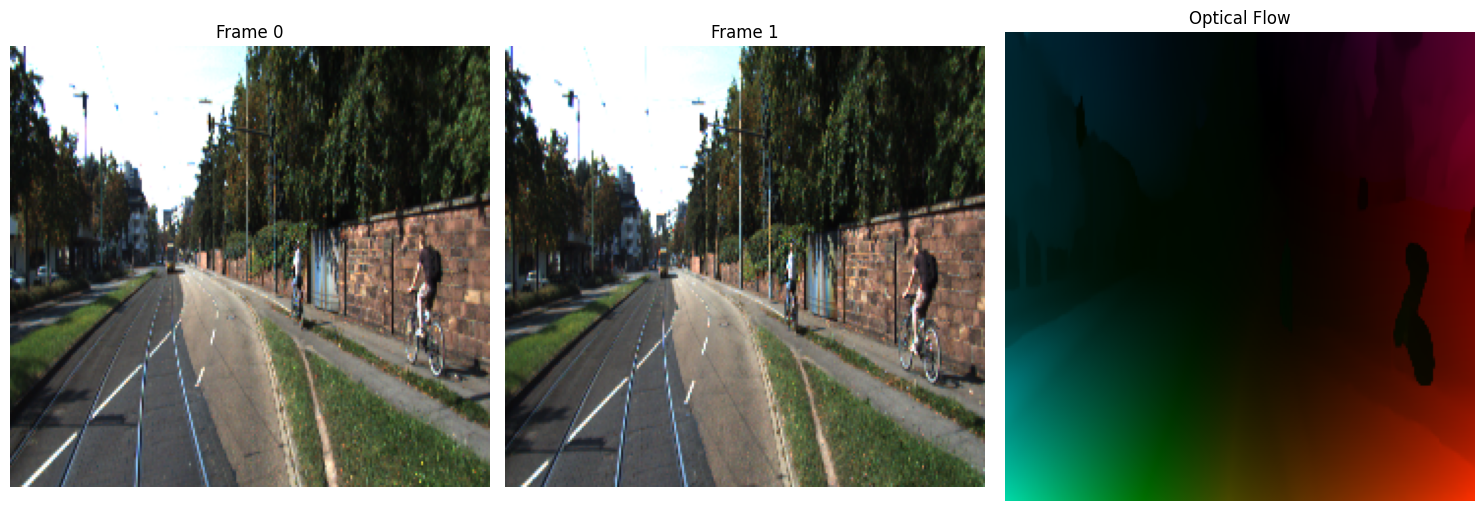

In [11]:
idx = 0

frame_img1 = cv2.imread(os.path.join(frames_dir, frames[idx]))
frame_img2 = cv2.imread(os.path.join(frames_dir, frames[idx+1]))
flow_img = plt.imread(os.path.join(flows_dir, f'flow_{idx}.png'))  # Loads as RGB

# Crop and resize frames
# frame_img1 = frame_img1[frame_img1.shape[0]//2 - 200: -200, :, :]
frame_img1 = cv2.resize(frame_img1, (244, 224))
frame_img1_rgb = cv2.cvtColor(frame_img1, cv2.COLOR_BGR2RGB)

# frame_img2 = frame_img2[frame_img2.shape[0]//2 - 200: -200, :, :]
frame_img2 = cv2.resize(frame_img2, (244, 224))
frame_img2_rgb = cv2.cvtColor(frame_img2, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(frame_img1_rgb)
axs[0].set_title('Frame 0')
axs[0].axis('off')
axs[1].imshow(frame_img2_rgb)
axs[1].set_title('Frame 1')
axs[1].axis('off')
axs[2].imshow(flow_img)
axs[2].set_title('Optical Flow')
axs[2].axis('off')
plt.tight_layout()

# Train Test Split

In [7]:
def create__indices(folder, random_state=42):
    image_files = [f for f in os.listdir(folder) if f.startswith('flow_') and f.endswith('.png')]
    indices = [int(f.split('_')[1].split('.')[0]) for f in image_files]
    
    # indices = sorted(indices)
    # missing = [i for i in range(indices[0], indices[-1]+1) if i not in indices]
    # print(missing)

    random.seed(random_state)
    random.shuffle(indices)
    return indices


train_indices = create__indices(r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\flows_process_then_resize', random_state=42)
val_indices =   create__indices(r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\flows_process_then_resize', random_state=42)

print(f"\nTrain indices: {train_indices[:10]} ... Total: {len(train_indices)}")
print(f"Val indices: {val_indices[:10]} ... Total: {len(val_indices)}")



Train indices: [100, 4997, 5355, 2043, 2690, 6837, 4421, 1476, 7513, 7317] ... Total: 9106
Val indices: [585, 136, 733, 159, 1797, 266, 928, 781, 868, 1503] ... Total: 2120


# Dataloader

In [7]:

class PreprocessedSpeedDataset(Dataset):
    def __init__(self, folder, speed_file, indices=None, transform=None):
        self.folder = folder
        self.transform = transform  

        if indices:
            self.flow_files = [os.path.join(folder, f'flow_{idx}.png') for idx in indices]
        else:
            self.flow_files = [os.path.join(folder, f'flow_{idx}.png') for idx in range(len(os.listdir(folder)))]

        all_speeds = [float(speed) for speed in open(speed_file).read().splitlines()]
        self.speed_files = [all_speeds[idx+1] for idx in indices] if indices else all_speeds
        
    
    def __len__(self):
        return len(self.flow_files)
    
    def __getitem__(self, idx):
        image = plt.imread(self.flow_files[idx])[:, :, :3]  # Ensure RGB format

        speed = self.speed_files[idx]
        speed = torch.tensor(speed, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, speed



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
])



In [8]:

train_flow_dir = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\flows_process_then_resize"
val_flow_dir =   r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\flows_process_then_resize"

train_speed_dir = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frame_speeds.txt"
val_speed_dir =   r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frame_speeds.txt"

train_dataset = PreprocessedSpeedDataset(train_flow_dir, train_speed_dir, train_indices, transform=transform)
val_dataset = PreprocessedSpeedDataset(val_flow_dir, val_speed_dir, val_indices, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, num_workers=0, shuffle=True, pin_memory=True)   # * 64 best, 32 2nd best
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=0, pin_memory=True)


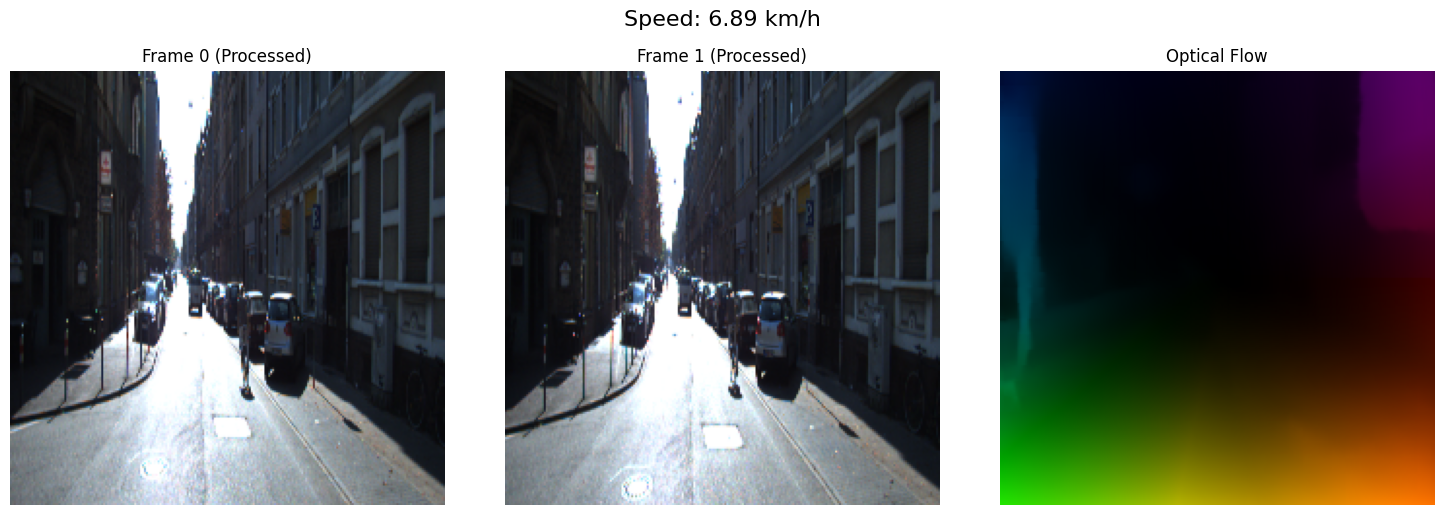

Speed value: 6.89
Flow image shape: (224, 224, 3)
Dataset returns: image tensor of shape torch.Size([3, 224, 224]), speed value 6.887383460998535


In [9]:
idx = 200
# idx = 0

# Create subplots to display frame0, frame1, flow, and speed
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Load and display frame0
frame0_path = os.path.join(frames_dir, frames[idx])
frame0 = cv2.imread(frame0_path)
frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
frame0 = cv2.resize(frame0, (224, 224))
frame0_processed_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)

axs[0].imshow(frame0_processed_rgb)
axs[0].set_title('Frame 0 (Processed)')
axs[0].axis('off')

# Load and display frame1
frame1_path = os.path.join(frames_dir, frames[idx + 1])
frame1 = cv2.imread(frame1_path)
frame1 = cv2.resize(frame1, (224, 224))
frame1_processed_rgb = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)

axs[1].imshow(frame1_processed_rgb)
axs[1].set_title('Frame 1 (Processed)')
axs[1].axis('off')

# Display optical flow from dataset
flow_image = train_dataset[idx][0].permute(1, 2, 0).numpy()
axs[2].imshow(flow_image)
axs[2].set_title('Optical Flow')
axs[2].axis('off')

# Get speed value from dataset
speed_value = train_dataset[idx][1].item()
fig.suptitle(f'Speed: {speed_value:.2f} km/h', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

print(f"Speed value: {speed_value:.2f}")
print(f"Flow image shape: {flow_image.shape}")
print(f"Dataset returns: image tensor of shape {train_dataset[idx][0].shape}, speed value {speed_value}")

# Train Model

In [9]:

class EfficientNetV2TinyModel(nn.Module):
    def __init__(self, pretrained=True, dropout_rate=0.1):
        super(EfficientNetV2TinyModel, self).__init__()
        
        self.base_model = timm.create_model('efficientnetv2_rw_t', pretrained=pretrained, num_classes=0)  # * Best

        num_features = self.base_model.num_features
        
        # Simpler head for tiny model
        self.head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 1),
        )
        
    def forward(self, x):
        features = self.base_model(x)
        output = self.head(features)
        return output
    
    
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        for images, speeds in val_loader:
            images = images.to(device)
            speeds = speeds.to(device)  
            
            # use autocast for inference if using AMP
            with autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs.squeeze(), speeds)

            total_loss += loss.item() * images.size(0)
            n += images.size(0)

    avg_loss = total_loss / n
    return avg_loss


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNetV2TinyModel(pretrained=True, dropout_rate=0.2).to(device)   # dropout 0.2 is best
criterion = nn.MSELoss()
# criterion = nn.L1Loss() # MAE Loss
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
# Scheduelr
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0.00001)

print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model: EfficientNetV2TinyModel
Parameters: 12,625,413


# Training Loop

In [ ]:

# ! LR Scheduler + Mixed Precision Training
# Import mixed precision training - Updated API

num_epochs = 25
best_loss = float('inf')

# Training with scheduler and mixed precision
scaler = GradScaler()  # Updated API
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0  
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=True)

    for batch_idx, (images, speeds) in enumerate(pbar):
        images = images.to(device)
        speeds = speeds.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass - Updated API
        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs.squeeze(), speeds)

        # Scale loss and backward pass
        scaler.scale(loss).backward()
        
        # Gradient clipping for stability
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update parameters
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({
            'Loss': f'{loss.item():.6f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.2e}'
        })
        
        # Clear cache periodically
        if batch_idx % 20 == 0:
            torch.cuda.empty_cache()


    avg_loss = running_loss / len(train_loader)
    
    # Step scheduler
    scheduler.step()

    # Validate at the end of each epoch
    val_loss = validate(model, val_loader, criterion, device)

    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Experiments\DPFlow_Cleaned\weights/best_model_normalized_efficientNetV2_process_then_resize_2.pth')
        print(f"New best model saved with loss: {val_loss:.6f}")

    print(f'\nEpoch {epoch+1}/{num_epochs}, Train Average Loss: {avg_loss:.6f}, Val Average Loss: {val_loss:.6f}, Val RMSE Loss: {np.sqrt(val_loss):.6f}, LR: {optimizer.param_groups[0]["lr"]:.2e}\n')

    # Clear cache after each epoch
    torch.cuda.empty_cache()

print(f"Training completed! Best loss: {best_loss:.6f}")
# End timing
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Training completed in {elapsed_time:.2f} seconds")
print(f"Training completed in {elapsed_time/60:.2f} minutes")


Epoch 1/25: 100%|██████████| 143/143 [00:19<00:00,  7.24it/s, Loss=1.458343, LR=1.00e-03]


New best model saved with loss: 2.323953

Epoch 1/25, Train Average Loss: 10.208387, Val Average Loss: 2.323953, Val RMSE Loss: 1.524452, LR: 9.96e-04



Epoch 2/25: 100%|██████████| 143/143 [00:20<00:00,  7.15it/s, Loss=3.801635, LR=9.96e-04]


New best model saved with loss: 1.905466

Epoch 2/25, Train Average Loss: 1.341589, Val Average Loss: 1.905466, Val RMSE Loss: 1.380386, LR: 9.84e-04



Epoch 3/25: 100%|██████████| 143/143 [00:19<00:00,  7.23it/s, Loss=0.964516, LR=9.84e-04]


...


Epoch 23/25, Train Average Loss: 0.061705, Val Average Loss: 4.395778, Val RMSE Loss: 2.096611, LR: 1.67e-05



Epoch 24/25: 100%|██████████| 143/143 [00:19<00:00,  7.24it/s, Loss=0.500088, LR=1.67e-05]



Epoch 24/25, Train Average Loss: 0.045957, Val Average Loss: 4.282368, Val RMSE Loss: 2.069388, LR: 4.94e-06



Epoch 25/25: 100%|██████████| 143/143 [00:19<00:00,  7.21it/s, Loss=0.063437, LR=4.94e-06]



Epoch 25/25, Train Average Loss: 0.042564, Val Average Loss: 4.114845, Val RMSE Loss: 2.028508, LR: 1.00e-06

Training completed! Best loss: 1.905466
Training completed in 560.77 seconds
Training completed in 9.35 minutes


# Evaluate

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNetV2TinyModel(pretrained=False, dropout_rate=0.2).to(device)   # Set pretrained=False when loading weights

# Load the trained weights
model_path = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_FYP_Cleaned\DPFlow_Modular_for_Lucentra\weights\best_weight_resize_2'
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()  # Set to evaluation mode

criterion = nn.L1Loss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0.00001)

print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Loaded weights from: {model_path}")

Model: EfficientNetV2TinyModel
Parameters: 12,625,413
Loaded weights from: D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_FYP_Cleaned\DPFlow_Modular_for_Lucentra\weights\best_weight_resize_2


In [13]:
criterion = nn.L1Loss()
mae_loss = validate(model, val_loader, criterion, device)
print(f'Validation MAE Loss: {mae_loss:.6f}')
criterion = nn.MSELoss()
mse_loss = validate(model, val_loader, criterion, device)
rmse_loss = np.sqrt(mse_loss)
print(f'Validation RMSE Loss: {rmse_loss:.6f}')
print(f'Validation MSE Loss: {mse_loss:.6f}')


Validation MAE Loss: 1.098596
Validation RMSE Loss: 1.380386
Validation MSE Loss: 1.905466


In [15]:

# Define the results file path
import csv
import time

curr_dir_base = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_FYP_Cleaned\DPFlow_Modular_for_Lucentra'
model_name = 'DPFlow'
results_file = os.path.join(curr_dir_base, r'Ablation_Studies\evaluation_results.csv')

# Measure inference time for 10 data elements
model.eval()
times = []
with torch.no_grad():
    for i in range(10):
        img, _ = val_dataset[i]
        img = img.unsqueeze(0).to(device)
        start = time.time()
        _ = model(img)
        end = time.time()
        times.append(end - start)
avg_inference_time = sum(times) / len(times)
print(f'Average inference time for 10 elements: {avg_inference_time:.4f} seconds')

# Check if file exists, if not, write header
if not os.path.exists(results_file):
    with open(results_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Model', 'MAE Loss', 'RMSE Loss', 'MSE Loss', 'Inference Time (s)'])

# Append the results
with open(results_file, 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([model_name, f"{mae_loss:.2f}", f"{rmse_loss:.2f}", f"{mse_loss:.2f}", f"{avg_inference_time:.4f}"])

print(f"Results saved to {results_file}")

Average inference time for 10 elements: 0.0097 seconds
Results saved to D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_FYP_Cleaned\DPFlow_Modular_for_Lucentra\Ablation_Studies\evaluation_results.csv


In [20]:
def any_nan(model, loader, device):
    model.eval()
    with torch.no_grad():
        for imgs, ys in loader:
            imgs = imgs.to(device)
            ys = ys.to(device)
            outs = model(imgs)
            if torch.isnan(outs).any() or torch.isnan(ys).any():
                return True
    return False

print("NaNs in val?", any_nan(model, val_loader, device))


NaNs in val? False


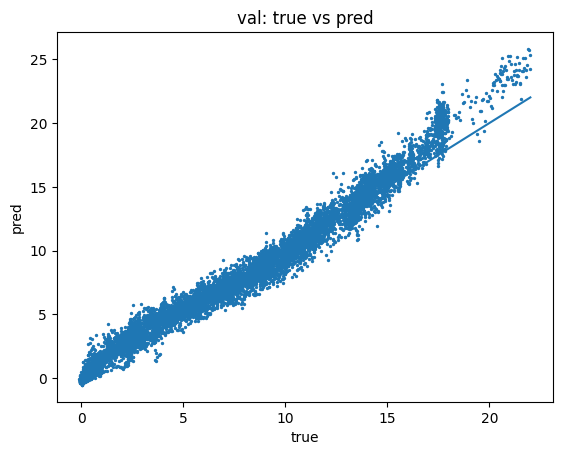

In [21]:
import matplotlib.pyplot as plt
model.eval()
ys_all, preds_all = [], []
with torch.no_grad():
    for imgs, ys in train_loader:
        imgs = imgs.to(device)
        outs = model(imgs).view(-1).cpu().numpy()
        preds_all.append(outs)
        ys_all.append(ys.view(-1).numpy())
preds = np.concatenate(preds_all)
ys = np.concatenate(ys_all)

# scatter (put in a .py, will open a window or save fig)
plt.scatter(ys, preds, s=2)
plt.xlabel("true")
plt.ylabel("pred")
plt.title("val: true vs pred")
plt.plot([ys.min(), ys.max()], [ys.min(), ys.max()])
plt.savefig("val_scatter.png", dpi=200)


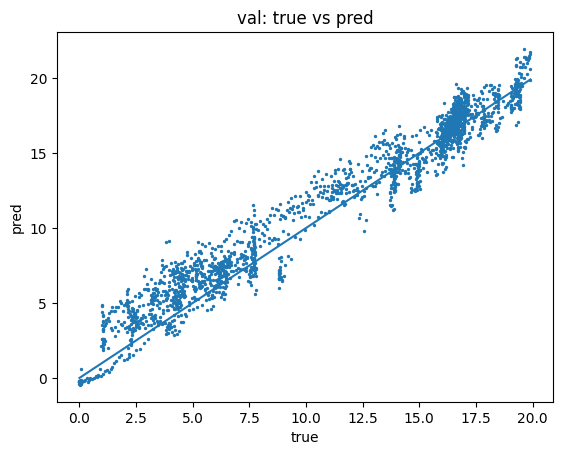

In [22]:
import matplotlib.pyplot as plt
model.eval()
ys_all, preds_all = [], []
with torch.no_grad():
    for imgs, ys in val_loader:
        imgs = imgs.to(device)
        outs = model(imgs).view(-1).cpu().numpy()
        preds_all.append(outs)
        ys_all.append(ys.view(-1).numpy())
preds = np.concatenate(preds_all)
ys = np.concatenate(ys_all)

# scatter (put in a .py, will open a window or save fig)
plt.scatter(ys, preds, s=2)
plt.xlabel("true")
plt.ylabel("pred")
plt.title("val: true vs pred")
plt.plot([ys.min(), ys.max()], [ys.min(), ys.max()])
plt.savefig("val_scatter.png", dpi=200)


In [20]:
def val_batch_stats(model, loader, criterion, device):
    model.eval()
    batch_losses = []
    with torch.no_grad():
        for imgs, ys in loader:
            imgs = imgs.to(device)
            ys = ys.view(-1).float().to(device)
            outs = model(imgs).view(-1)
            batch_loss = ((outs - ys)**2).mean().item()   # batch MSE
            batch_losses.append(batch_loss)
    import numpy as np
    return np.mean(batch_losses), np.std(batch_losses), np.max(batch_losses), np.percentile(batch_losses, 90)

print("batch mean, std, max, 90p:", val_batch_stats(model, val_loader, criterion, device))


batch mean, std, max, 90p: (np.float64(5.311080861447462), np.float64(2.129587562318683), np.float64(12.428778648376465), np.float64(7.7503005981445305))


In [19]:
import numpy as np

def label_stats(loader):
    ys = []
    for _, y in loader:
        ys.append(y.view(-1).numpy())
    ys = np.concatenate(ys)
    return {
        'mean': ys.mean(), 'std': ys.std(),
        'min': ys.min(), 'max': ys.max(),
        'p10': np.percentile(ys,10), 'p50': np.percentile(ys,50), 'p90': np.percentile(ys,90)
    }

print("Train labels:", label_stats(train_loader))
print("Val   labels:", label_stats(val_loader))


Train labels: {'mean': np.float32(8.078086), 'std': np.float32(5.4035563), 'min': np.float32(-0.097603306), 'max': np.float32(22.009907), 'p10': np.float32(0.5352056), 'p50': np.float32(7.9205303), 'p90': np.float32(15.348415)}
Val   labels: {'mean': np.float32(10.828528), 'std': np.float32(6.074147), 'min': np.float32(0.0026199452), 'max': np.float32(19.903751), 'p10': np.float32(2.3781836), 'p50': np.float32(12.386826), 'p90': np.float32(17.330305)}


In [3]:
import timm
import torch.nn as nn
import pandas as pd
from IPython.display import display

# Instantiate the EfficientNetV2-RW-Tiny model
base_model = timm.create_model('efficientnetv2_rw_t', pretrained=False)

# Collect layer information
layer_data = []

# Iterate through named modules to get names and types
# We only want actual layers (like Conv2d, Linear, BatchNorm2d) not containers (like Sequential or the whole Model)
for name, module in base_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear, nn.BatchNorm2d, nn.SiLU, nn.Identity, nn.AdaptiveAvgPool2d, nn.Dropout, nn.Hardswish)):
        # Optional: You can get parameters count as well
        params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        layer_data.append({"Layer Name": name, "Layer Type": module.__class__.__name__, "Trainable Parameters": params})
    
# Create a DataFrame
df_layers = pd.DataFrame(layer_data)

# Set pandas options to display all rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Display the table
# display(df_layers)

# If you want to reset pandas options back to default after 
# pd.reset_option('display.max_rows')

# Count total modules (including containers like Sequential)
total_modules = sum(1 for _ in base_model.modules())

# Count specific trainable layers (Conv2d, Linear, BatchNorm)
trainable_layers = sum(1 for m in base_model.modules() if isinstance(m, (nn.Conv2d, nn.Linear, nn.BatchNorm2d)))

# Count only Conv2d and Linear layers
conv_linear_layers = sum(1 for m in base_model.modules() if isinstance(m, (nn.Conv2d, nn.Linear)))

print(f"\nTotal modules (including containers): {total_modules}")
print(f"Total trainable layers (Conv, Linear, BatchNorm): {trainable_layers}")
print(f"Total Conv2d & Linear layers: {conv_linear_layers}")


Total modules (including containers): 710
Total trainable layers (Conv, Linear, BatchNorm): 273
Total Conv2d & Linear layers: 166
